# Generating plots in Figures

This notebook contains the code for generating plots in the Figures. It uses the data generated from the other notebooks.

In [465]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pickle
from collections import defaultdict
from scipy.stats import linregress

In [411]:
threshold = 10 ** -7

In [413]:
# Analytical formulas for fixation probability

# Kimura's formula
def fix_prob_theory(p, N, s):
    return (1 - np.exp(-N * s * p)) / (1 - np.exp(-N * s))

# Theory with ecology
def corrected_fix_prob_theory(p, N, a, s):
    def helper(x):
        return sp.special.erfi((a * x + s) * np.sqrt(N / 2 / a))
    return (helper(p) - helper(0)) / (helper(p) - helper(p - 1))

## Figure 1 (and trajectory plots in Figure 3)

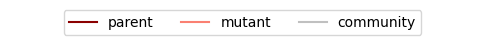

In [415]:
# Plot trajectory of species abundances and other quantities given plot data from simulation function

def plot_trajectory(plot_data, steady_state=False, figsize=(3,1.875), filename=None, xlim=None):
    plt.figure(figsize=figsize)
    x_axis = plot_data['x_axis']
    parent = plot_data['parent']
    plt.plot(x_axis, plot_data['Abundances'], c='silver',linewidth=0.3)
    plt.plot(x_axis, plot_data['Abundances'][:, parent], c='darkred', label='parent')
    plt.plot(x_axis, plot_data['Abundances'][:, -1], c='salmon', label='mutant')
    if steady_state:
        plt.axhline(plot_data['Parent steady state'], c='darkred', label='parent_steady')
        plt.axhline(plot_data['Mutant steady state'], c='salmon', label='mutant_steady')
    plt.xlabel('Time')
    plt.ylabel('Abundance')
    plt.tight_layout()
    
    if xlim is not None:
        plt.xlim(*xlim)
    if filename is not None:
        plt.savefig(filename)
    plt.show()

# Generate the legend for the trajectory plots

def plot_legend():
    # Create dummy lines for legend
    dummy_parent = plt.Line2D([], [], c='darkred', label='parent')
    dummy_mutant = plt.Line2D([], [], c='salmon', label='mutant') 
    dummy_community = plt.Line2D([], [], c='silver', label='community')

    # Create figure just for legend
    legend_fig = plt.figure(figsize=(6, 0.3))
    legend_fig.legend(handles=[dummy_parent, dummy_mutant, dummy_community], 
                     loc='center', ncol=4)
    plt.axis('off')
    
plot_legend()
plt.savefig('parent_mutant_legend.pdf')


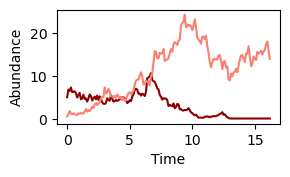

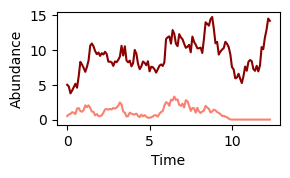

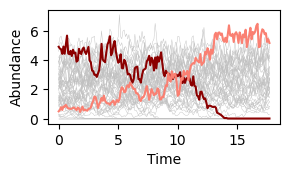

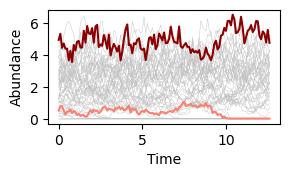

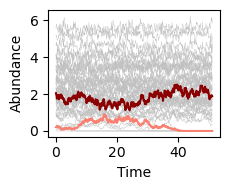

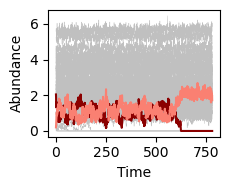

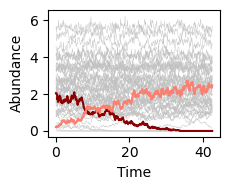

In [62]:
with open('trajectories_trad.pkl', 'rb') as f:
    plot_catalog = pickle.load(f)['data']
    
plot_trajectory(plot_catalog['fixate'],filename='fixate.pdf')
plot_trajectory(plot_catalog['extinct'],filename='extinct.pdf')

with open('trajectories.pkl', 'rb') as f:
    plot_catalog = pickle.load(f)['data']

plot_trajectory(plot_catalog['fixate as expected'],filename='fixate as expected.pdf')
plot_trajectory(plot_catalog['extinct as expected'],filename='extinct as expected.pdf')

with open('trajectories_coexistence.pkl', 'rb') as f:
    plot_data = pickle.load(f)['data']

for s in plot_data:
    data = plot_data[s]
    if len(data['x_axis']) > 5000:
        data['x_axis'] = data['x_axis'][::5]
        data['Abundances'] = data['Abundances'][::5]
    plot_trajectory(data,figsize=(2.4,2),filename='trajectory_coexistence'+str(s)+'.pdf')

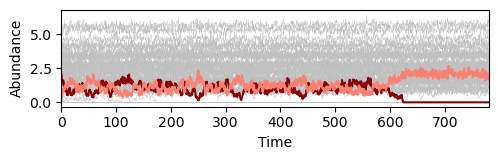

In [67]:
s=0.2
data = plot_data[s]
if len(data['x_axis']) > 5000:
    data['x_axis'] = data['x_axis'][::5]
    data['Abundances'] = data['Abundances'][::5]
plot_trajectory(data,figsize=(5,1.7),xlim=(0,780),filename='trajectory_coexistence'+str(s)+'.pdf')

## Figure 2

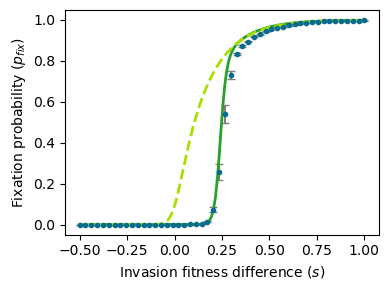

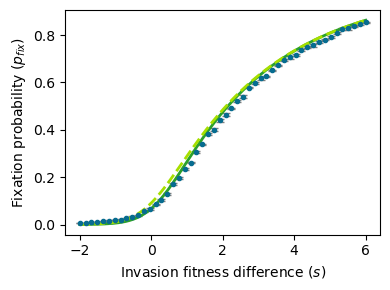

In [44]:
with open('fixation_prob.pkl', 'rb') as f:
    results = pickle.load(f)

portion = results['portion']

survivor = results['n0'] > threshold
A_survive = results['A'][:, survivor][survivor, :]
susceptibility = np.trace(np.linalg.inv(A_survive)) / sum(survivor)
TAP = 1 - results['rho_a'] * results['sigma_a'] ** 2 * susceptibility
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)
eta = 2 * Npm * (1 - results['rho_mutant']) * TAP

for temperature in results['data']:
    plt.figure(figsize=(4,3))
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    s_samples = np.linspace(np.min(s_list), np.max(s_list), 150)
    mean_probs = np.mean(trials, axis=0)
    err_probs = np.std(trials, axis=0) / np.sqrt(len(trials))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o', markersize=3, capsize=3, label='Simulations', c='#076C90', ecolor='gray')

    N_eff = Npm / temperature
    p_theory = corrected_fix_prob_theory(portion / (1 + portion), N_eff, eta, s_samples)
    
    p_kimura = fix_prob_theory(portion / (1 + portion), N_eff, s_samples)
    plt.plot(s_samples, p_theory, c='#2CA02C', label='Theory with ecology',linewidth=2)

    plt.plot(s_samples, p_kimura, c='#A6DF00',linestyle='dashed', label='Kimura',linewidth=2)
   
    plt.xlabel('Invasion fitness difference ($s$)')
    plt.ylabel('Fixation probability ($p_{fix}$)')
    plt.tight_layout()
    plt.gca().set_facecolor('none')
    plt.gcf().patch.set_alpha(0.0)
    plt.savefig(f"fix_p_vs_ifd_june_talk_ecology_T{temperature}.pdf")
    plt.show()
# Create a separate figure for the legend
plt.figure(figsize=(4,1))
ax = plt.gca()

# Create dummy plots with the same styles as the main figure
plt.errorbar([], [], fmt='o', markersize=3, c='#076C90', label='Simulations', capsize=3, yerr=0.1, ecolor='gray')
plt.plot([], [], c='#2CA02C', linewidth=2, label='Theory with ecology')
plt.plot([], [], c='#A6DF00', linestyle='dashed', linewidth=2, label='Kimura')

# Get the legend
legend = plt.legend(ncol=3, loc='center', frameon=False)

# Remove the axes
ax.set_axis_off()

# Save just the legend
plt.savefig('figure2_legend.pdf', bbox_inches='tight')
plt.close()


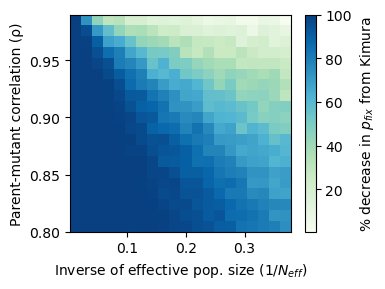

In [9]:
with open('phase_diagram.pkl', 'rb') as f:
    results = pickle.load(f)
plt.figure(figsize=(4,3))

temp_range = results['temperature']
rho_range = results['rho_mutant']
probs = results['data']
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)

Z = np.zeros((len(rho_range), len(temp_range)))
for i, y in enumerate(rho_range):
    for j, x in enumerate(temp_range):
        Z[i, j] = (1-(np.mean(probs[(x, y)])) / portion * (1 + portion)) * 100

plt.imshow(
    Z,
    extent=[2 * temp_range.min() / Npm, 2 * temp_range.max() / Npm, rho_range.min(), rho_range.max()],
    origin='lower',
    cmap='GnBu',
    aspect='auto'
)
plt.colorbar(label='% decrease in $p_{fix}$ from Kimura')
plt.xlabel('Inverse of effective pop. size ($1/N_{eff}$)')
plt.ylabel('Parent-mutant correlation (ρ)')
plt.tight_layout()
plt.savefig('phase_diagram.pdf')

plt.show()

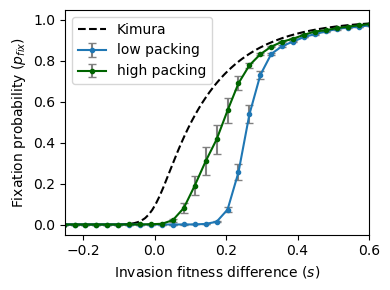

In [45]:
with open('fixation_prob.pkl', 'rb') as f:
    results = pickle.load(f)

plt.figure(figsize=(4,3))

for temperature in results['data']:
    if temperature > 0.5:
        continue
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, ecolor='gray', label=f'low packing')
    # plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='C0', linestyle='dotted')

with open('fixation_prob_more_packed.pkl', 'rb') as f:
    results = pickle.load(f)

for temperature in results['data']:
    if temperature > 0.5:
        continue
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, ecolor='gray', label=f'high packing', color='darkgreen')

portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)

s_samples = np.linspace(np.min(s_list), np.max(s_list), 150)
N_eff = Npm / temperature
p_theory = fix_prob_theory(portion / (1 + portion), N_eff, s_samples)
plt.plot(s_samples, p_theory, c='black',linestyle='dashed', label='Kimura')

plt.xlabel('Invasion fitness difference ($s$)')
plt.ylabel('Fixation probability ($p_{fix}$)')
plt.legend(loc='upper left')
plt.xlim(-0.25, 0.6)
plt.tight_layout()
plt.savefig("packing_fraction_effect_glv.pdf")
plt.show()

## Figure 3

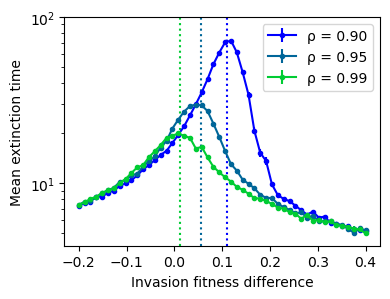

In [12]:
with open('extinction_time_vary_rho.pkl', 'rb') as f:
    results = pickle.load(f)

portion = results['portion']
parent = results['parent']
n0 = results['n0']
survivor = n0 > threshold
A_survive = results['A'][:, survivor][survivor, :]
susceptibility = np.trace(np.linalg.inv(A_survive)) / sum(survivor)
TAP = 1 - results['rho_a'] * results['sigma_a'] ** 2 * susceptibility
# Create a gradient from blue to green with different luminosity
colors = ['#0000FF', '#006699', '#00CC33']  # Blue to green gradient with varying brightness

plt.figure(figsize=(4, 3.1))

for rho_mutant, color in zip(sorted(list(results['data'].keys())), ['C0', 'C1', 'C2']):
    extinction_time = results['data'][rho_mutant]
    s_list = sorted(list(extinction_time.keys()))
    mean_extinction_time = [np.mean(np.array(extinction_time[s])) for s in s_list]
    err_extinction_time = [np.std(np.array(extinction_time[s])) / np.sqrt(len(extinction_time[s])) for s in s_list]
    plt.errorbar(s_list, mean_extinction_time, yerr=err_extinction_time, fmt='o-', label=f'ρ = {rho_mutant:.2f}', c=colors[sorted(list(results['data'].keys())).index(rho_mutant)],markersize=3)
    eta = 2 * results['n0'][parent] * (1 + portion) * (1 - rho_mutant) * TAP
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), linestyle='dotted', c=colors[sorted(list(results['data'].keys())).index(rho_mutant)])

plt.xlabel('Invasion fitness difference')
plt.ylabel('Mean extinction time')
plt.yscale('log')
plt.ylim(top=1e2)

plt.legend()
plt.tight_layout()
plt.savefig("extinction_time_vary_rho.pdf")

plt.show()

0.02
0.024
0.036


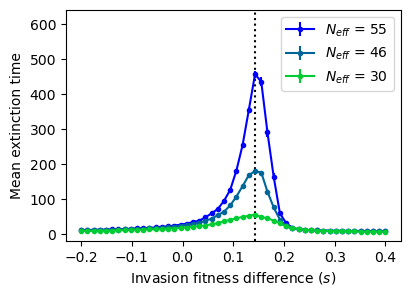

0.02
0.024
0.036


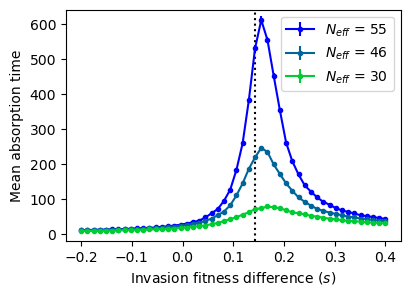

In [486]:
with open('coexistence_time_vary_D_0.pkl', 'rb') as f:
    results = pickle.load(f)
    
rho_mutant = results['rho_mutant']
portion = results['portion']
parent = results['parent']
Npm = results['n0'][parent] * (1 + portion)
survivor = results['n0'] > threshold
A_survive = results['A'][:, survivor][survivor, :]
susceptibility = np.trace(np.linalg.inv(A_survive)) / sum(survivor)
TAP = 1 - results['rho_a'] * results['sigma_a'] ** 2 * susceptibility


# Create a gradient from blue to green with different luminosity
colors = ['#0000FF', '#006699', '#00CC33']  # Blue to green gradient with varying brightness
curves = [4, 3, 1]

for outcomes, label, filename in zip(
    [('extinct',), ('extinct', 'fixate')], 
    ['Mean extinction time', 'Mean absorption time'],
    ['extinction_time_vary_D.pdf', 'extinction_fixation_time_vary_D.pdf']
):
    plt.figure(figsize=(4.32, 3))
    for index, color in zip(curves, colors):
        with open('coexistence_time_vary_D_' + str(index) + '.pkl', 'rb') as f:
            results = pickle.load(f)
        temperature = results['temperature']
        print(temperature)
        s_list = sorted(list(results['data']['extinct'].keys()))
        time = defaultdict(list)
        for s in s_list:
            for outcome in outcomes:
                time[s] += results['data'][outcome][s]
        mean_time = [np.mean(time[s]) for s in s_list]
        err_time = [np.std(time[s]) / np.sqrt(len(time[s])) for s in s_list]
        plt.errorbar(np.array(s_list), mean_time, yerr=err_time, fmt='o-', label=f'$N_{{eff}}$ = {round(Npm / 2 / temperature)}', c=color,markersize=3)
    eta = 2 * results['n0'][parent] * (1 + portion) * (1 - rho_mutant) * TAP
    
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), linestyle='dotted', c='black')
    
    
    plt.xlabel('Invasion fitness difference ($s$)')
    plt.ylabel(label)
    # plt.yscale('log')
    plt.legend()
    plt.ylim(-20,640)
    plt.savefig(filename, bbox_inches='tight')
    
    plt.show()


In [403]:
# Generate plots for selection-drift ratio

from matplotlib.patches import Rectangle
from matplotlib.patches import FancyArrowPatch

def selection_drift_ratio_plot(s, eta, Nd, f0=0, y_min=0, y_max=3, arrow_intervals=None, coexistence=None, filename=None):
    # The ratio
    def f(x, f0):
        return np.abs(s - eta * (x - f0)) * x * Nd
    
    # Plotting domain and range
    x_min, x_max = 0, 1
    # y_min, y_max = 0, 3
    separator_y = 1
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(3, 2))
    
    # Selection and drift dominated regimes
    ax.add_patch(Rectangle((x_min, y_min), x_max - x_min-1, separator_y - y_min,
                           facecolor='#FEFAF0', alpha=0.3, zorder=1))
    ax.add_patch(Rectangle((x_min, separator_y), x_max - x_min, y_max - separator_y,
                           facecolor='#DCFFFD', alpha=0.3, zorder=1))
    
    # Plot the curve
    x = np.linspace(x_min, x_max, 1000)
    y = f(x, f0)
    ax.plot(x, y, color='black', linewidth=2, zorder=3)
    
    # Crossover at ratio = 1
    ax.axhline(separator_y, color='black', linestyle='--', linewidth=1)

    # Add arrows to show the direction of deterministic dynamics
    def add_arrow_on_curve(x1, x2, n_points):
        xs = np.linspace(x1, x2, n_points)
        ys = f(xs, f0)
        for i in range(n_points - 1):
            start = (xs[i], ys[i])
            end = (xs[i+1], ys[i+1])
            arrow = FancyArrowPatch(start, end,
                                    arrowstyle='->', color='SeaGreen',
                                    linewidth=2, mutation_scale=20, zorder=5)
            ax.add_patch(arrow)

    if arrow_intervals is not None:
        for x1, x2, n_points in arrow_intervals:
            add_arrow_on_curve(x1, x2, n_points)

    if coexistence is not None:
        f2, f3 = coexistence
        ax.add_patch(Rectangle((f2, 0), f3 - f2, y_max,
                           facecolor='#B82025', alpha=0.3, zorder=1))
        ax.axvline(f2, color='salmon', linestyle='--', linewidth=1.5)
        ax.axvline(f3, color='salmon', linestyle='--', linewidth=1.5)
    
    # --- Plot formatting ---
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Mutant frequency ($f$)')
    ax.set_ylabel('Selection/drift ratio')
    ax.set_aspect('auto')
    if filename is not None:
        plt.savefig(filename, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()


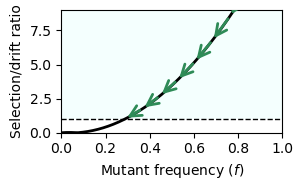

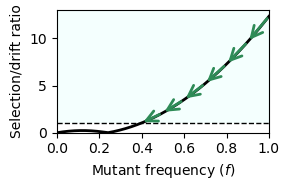

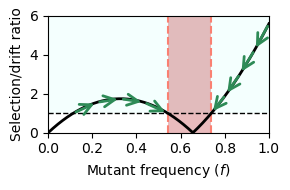

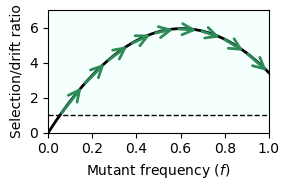

In [405]:
eta, Nd, f0 = 0.36, 45, 0.1

s = -0.01
arrow_intervals = [(1, 2 / Nd / abs(s + eta * f0) / (np.sqrt(1 + 4 * eta / Nd / (s + eta * f0) ** 2) - 1), 10)]
selection_drift_ratio_plot(s, eta, Nd, f0=0.1, y_max=9, arrow_intervals=arrow_intervals, filename='R_deleterious.pdf')

s = 0.05
arrow_intervals = [(1, 2 / Nd / abs(s + eta * f0) / (np.sqrt(1 + 4 * eta / Nd / (s + eta * f0) ** 2) - 1), 7)]
selection_drift_ratio_plot(s, eta, Nd, f0=0.1, y_max=13, arrow_intervals=arrow_intervals, filename='R_beneficial_suppressed.pdf')

s = 0.2
f1 = 2 / Nd / abs(s + eta * f0) / (np.sqrt(1 - 4 * eta / Nd / (s + eta * f0) ** 2) + 1)
f2 = 2 / Nd / abs(s + eta * f0) / (-np.sqrt(1 - 4 * eta / Nd / (s + eta * f0) ** 2) + 1)
f3 = 2 / Nd / abs(s + eta * f0) / (np.sqrt(1 + 4 * eta / Nd / (s + eta * f0) ** 2) - 1)
arrow_intervals = [(f1, f2, 5), (1, f3, 5)]
selection_drift_ratio_plot(s, eta, Nd, f0=0.1, y_max=6, arrow_intervals=arrow_intervals, coexistence=(f2, f3), filename='R_beneficial_coexist.pdf')

s = 0.4
arrow_intervals = [(2 / Nd / abs(s + eta * f0) / (np.sqrt(1 - 4 * eta / Nd / (s + eta * f0) ** 2) + 1), 1, 10)]
selection_drift_ratio_plot(s, eta, Nd, f0=0.1, y_max=7, arrow_intervals=arrow_intervals, filename='R_establishment.pdf')

## Figure 4

In [57]:
# Generate plots for frequency dynamics with crossover regimes

def plot_frequency(plot_data, figsize=(4,2.5
                                      ), filename=None, xlim=None, barrier=None, coexistence=None):
    dt = 0.1
    fig, ax = plt.subplots(figsize=figsize)
    x_axis = plot_data['x_axis']
    frequencies = np.exp(plot_data['Log mutant fraction'])
    frequencies = np.concatenate((frequencies, np.full(5 * len(x_axis), frequencies[-1])))
    x_axis = np.concatenate((x_axis, np.linspace(x_axis[-1] + dt, 6 * x_axis[-1], 5 * len(x_axis))))

    # Drift barrier
    if barrier is not None:
        ax.axhline(barrier, color='gray', linestyle='--', linewidth=1.5)

    # Coexistence region
    if coexistence is not None:
        f2, f3 = coexistence
        ax.add_patch(Rectangle((1, f2), max(x_axis) - 1, f3 - f2,
                           facecolor='#B82025', alpha=0.3, zorder=1))
        ax.axhline(f2, color='salmon', linestyle='--', linewidth=1.5)
        ax.axhline(f3, color='salmon', linestyle='--', linewidth=1.5)
    
    ax.plot(x_axis, frequencies, color='#440902',linewidth=0.8)
    ax.set_xlabel('Time')
    ax.set_ylabel('Mutant frequency ($f$)')
    ax.set_xscale('log')
    ax.set_xlim(1, max(x_axis))
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    
    if xlim is not None:
        ax.set_xlim(*xlim)
    if filename is not None:
        plt.savefig(filename)
    plt.show()

1.9909372691684517
0.14097587644469742


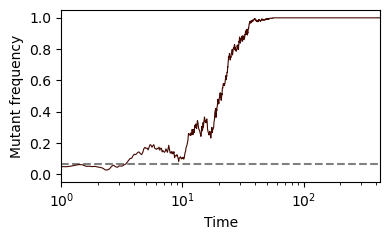

0.08810992277793588


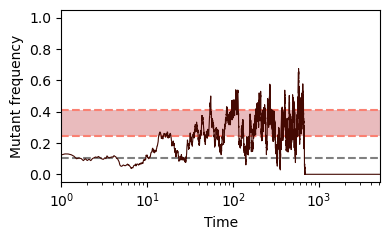

0.22908579922263328


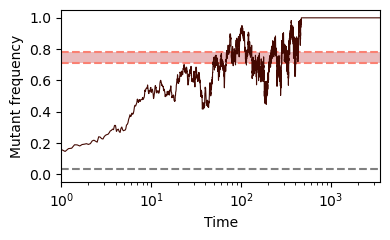

In [493]:
with open('mutant_frequencies.pkl', 'rb') as f:
    results = pickle.load(f)

plot_catalog = results['data']
eta = results['eta']
Nd = results['n0'][results['parent']] * (1 + results['portion']) / 2 / results['temperature']
print(results['n0'][results['parent']])
f0 = 0.1

s = eta * 0.4
print(s)
barrier = 1 / Nd / s
plot_frequency(plot_catalog['popgen'], barrier=barrier, filename='mutant_frequency_popgen.pdf')
for s in plot_catalog['ecology']:
    print(s)
    f1 = 2 / Nd / abs(s + eta * f0) / (np.sqrt(1 - 4 * eta / Nd / (s + eta * f0) ** 2) + 1)
    f2 = 2 / Nd / abs(s + eta * f0) / (-np.sqrt(1 - 4 * eta / Nd / (s + eta * f0) ** 2) + 1)
    f3 = 2 / Nd / abs(s + eta * f0) / (np.sqrt(1 + 4 * eta / Nd / (s + eta * f0) ** 2) - 1)
    plot_frequency(plot_catalog['ecology'][s], barrier=f1, coexistence=(f2, f3), filename=f'mutant_frequency_ecology{s:.1f}.pdf')

## Figure S1

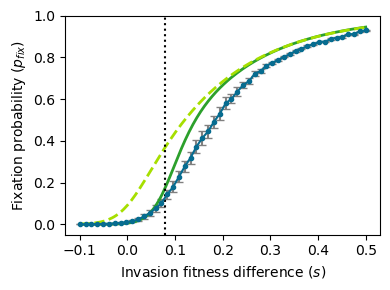

In [497]:
with open('fixation_prob_crm.pkl', 'rb') as f:
    results = pickle.load(f)

portion = results['portion']
n_survivor = (results['n0'] > threshold)
r_survivor = (results['r0'] > threshold)
C_survive = results['C'][n_survivor, :][:, r_survivor]
E_survive = results['E'][n_survivor, :][:, r_survivor]
M = results['M']
M_survive = sum(r_survivor)
susceptibility = np.trace(np.identity(M_survive) - E_survive.T @ np.linalg.inv(C_survive @ E_survive.T) @ C_survive) / M
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)
eta = 2 * Npm * (1 - results['rho_mutant']) * results['kappa'] * (results['sigma'] ** 2) * susceptibility

for temperature in results['data']:
    plt.figure(figsize=(4,3))
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    s_samples = np.linspace(np.min(s_list), np.max(s_list), 150)
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, label='Simulations', c='#076C90', ecolor='gray')

    N_eff = Npm / temperature
    p_theory = corrected_fix_prob_theory(portion / (1 + portion), N_eff, eta, s_samples)
    
    p_kimura = fix_prob_theory(portion / (1 + portion), N_eff, s_samples)
    plt.plot(s_samples, p_theory, c='#2CA02C', label='Theory with ecology',linewidth=2)

    plt.plot(s_samples, p_kimura, c='#A6DF00',linestyle='dashed', label='Kimura',linewidth=2)
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='black', linestyle='dotted')
    

    plt.xlabel('Invasion fitness difference ($s$)')
    plt.ylabel('Fixation probability ($p_{fix}$)')
    plt.ylim(-0.05, 1)
    plt.tight_layout()
    plt.gca().set_facecolor('none')
    plt.gcf().patch.set_alpha(0.0)
    plt.savefig("fix_p_crm.pdf")
    plt.show()

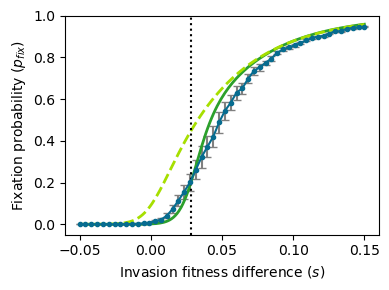

In [504]:
# Calculate eta by averaging across different mutants

def mutant(parent, rho_mutant):
    zc_p = (C[parent] - mu / M) / (sigma / np.sqrt(M))
    z = np.random.normal(size=M)
    zc_m = rho_mutant * zc_p + np.sqrt(1 - rho_mutant ** 2) * z
    C_m = mu / M + sigma / np.sqrt(M) * zc_m
    C_invade = np.vstack((C, C_m))
    return C_invade

with open('fixation_prob_ecrm.pkl', 'rb') as f:
    results = pickle.load(f)

portion = results['portion']
parent = results['parent']
rho_mutant = results['rho_mutant']
n0 = results['n0']
r0 = results['r0']
Npm = n0[parent] * (1 + portion)
M = results['M']
C = results['C']
mu = results['mu']
sigma = results['sigma']
eta_trial = []
for _ in range(1000):
    n_survivor = (n0 > threshold)
    C_invade = mutant(parent, rho_mutant)
    E_invade = C_invade * r0
    C_survive = C[n_survivor, :]
    E_survive = C_survive * r0
    Qinv = np.diag(1 / (1 + C.T @ n0))
    P = Qinv @ E_survive.T @ np.linalg.inv(C_survive @ Qinv @ E_survive.T) @ C_survive
    eta_trial.append(Npm * (C_invade[-1, :] - C_invade[parent, :]) @ (np.identity(M) - P) @ Qinv @ (E_invade[-1, :] - E_invade[parent, :]))
eta = np.mean(eta_trial)
Npm = results['n0'][results['parent']] * (1 + portion)

for temperature in results['data']:
    plt.figure(figsize=(4,3))
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    s_samples = np.linspace(np.min(s_list), np.max(s_list), 150)
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, label='Simulations', c='#076C90', ecolor='gray')

    N_eff = Npm / temperature
    p_theory = corrected_fix_prob_theory(portion / (1 + portion), N_eff, eta, s_samples)
    
    p_kimura = fix_prob_theory(portion / (1 + portion), N_eff, s_samples)
    plt.plot(s_samples, p_theory, c='#2CA02C', label='Theory with ecology',linewidth=2)

    plt.plot(s_samples, p_kimura, c='#A6DF00',linestyle='dashed', label='Kimura',linewidth=2)
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='black', linestyle='dotted')
    

    plt.xlabel('Invasion fitness difference ($s$)')
    plt.ylabel('Fixation probability ($p_{fix}$)')
    plt.ylim(-0.05, 1)
    plt.tight_layout()
    plt.gca().set_facecolor('none')
    plt.gcf().patch.set_alpha(0.0)
    plt.savefig("fix_p_linear_resource_crm.pdf")
    plt.show()

## Figure S2

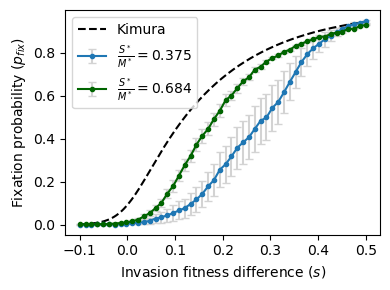

In [508]:
with open('fixation_prob_crm_less_packed.pkl', 'rb') as f:
    results = pickle.load(f)

plt.figure(figsize=(4,3))

packing_fraction = sum(results['n0'] > threshold) / sum(results['r0'] > threshold)

portion = results['portion']
n_survivor = (results['n0'] > threshold)
r_survivor = (results['r0'] > threshold)
C_survive = results['C'][n_survivor, :][:, r_survivor]
E_survive = results['E'][n_survivor, :][:, r_survivor]
M = results['M']
M_survive = sum(r_survivor)
susceptibility = np.trace(np.identity(M_survive) - E_survive.T @ np.linalg.inv(C_survive @ E_survive.T) @ C_survive) / M
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)
eta = 2 * Npm * (1 - results['rho_mutant']) * results['kappa'] * (results['sigma'] ** 2) * susceptibility


for temperature in results['data']:
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, ecolor='lightgray', label=fr'$\frac{{S^*}}{{M^*}}={packing_fraction:.3f}$')
    #plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='C0', linestyle='dotted')

with open('fixation_prob_crm.pkl', 'rb') as f:
    results = pickle.load(f)

packing_fraction = sum(results['n0'] > threshold) / sum(results['r0'] > threshold)

portion = results['portion']
n_survivor = (results['n0'] > threshold)
r_survivor = (results['r0'] > threshold)
C_survive = results['C'][n_survivor, :][:, r_survivor]
E_survive = results['E'][n_survivor, :][:, r_survivor]
M = results['M']
M_survive = sum(r_survivor)
susceptibility = np.trace(np.identity(M_survive) - E_survive.T @ np.linalg.inv(C_survive @ E_survive.T) @ C_survive) / M
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)
eta = 2 * Npm * (1 - results['rho_mutant']) * results['kappa'] * (results['sigma'] ** 2) * susceptibility

for temperature in results['data']:
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, ecolor='lightgray', label=fr'$\frac{{S^*}}{{M^*}}={packing_fraction:.3f}$', color='darkgreen')
    #plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='C1', linestyle='dotted')

s_samples = np.linspace(np.min(s_list), np.max(s_list), 150)
N_eff = Npm / temperature
p_theory = fix_prob_theory(portion / (1 + portion), N_eff, s_samples)
plt.plot(s_samples, p_theory, c='black',linestyle='dashed', label='Kimura')

plt.xlabel('Invasion fitness difference ($s$)')
plt.ylabel('Fixation probability ($p_{fix}$)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("packing_fraction_effect.pdf")
plt.show()

## Figure S3

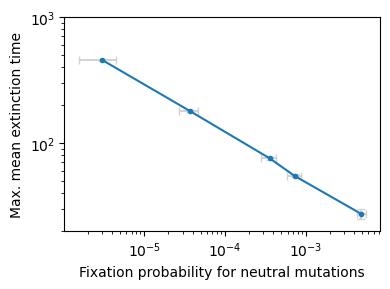

In [522]:
x = []
x_err = []
y = []
y_err = []
points = [0, 1, 2, 3, 4]

plt.figure(figsize=(4, 3))

with open('coexistence_neutral_fix_prob.pkl', 'rb') as f:
    probs = pickle.load(f)
    
for i in points:
    with open('coexistence_time_vary_D_' + str(i) + '.pkl', 'rb') as f:
        results = pickle.load(f)
    extinction_time = results['data']['extinct']
    s_list = sorted(list(extinction_time.keys()))
    s_list = [s for s in s_list if 0 < s < 0.3]
    time = np.array(extinction_time[s_list[np.argmax([np.mean(np.array(extinction_time[s])) for s in s_list])]])
    mean_time = np.mean(time)
    err_time = np.std(time) / np.sqrt(len(time))
    x.append(np.mean(probs[i]))
    x_err.append(np.std(probs[i]) / np.sqrt(len(probs[i])))
    y.append(mean_time)
    y_err.append(err_time)
plt.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o-', 
             markersize=3, capsize=3, ecolor='lightgray')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Fixation probability for neutral mutations')
plt.ylabel('Max. mean extinction time')
plt.ylim(20, 1000)
plt.tight_layout()
plt.savefig('extinction_time_vs_fix_prob.pdf', bbox_inches='tight')
plt.show()